# From the NASA Exoplanet Archive, data is downloaded and analyzed in order to determine from which planet the data is taken

In [1]:
import numpy as np                #importing useful modules
from astropy.table import Table
from astropy.io import ascii
import matplotlib.pyplot as plt
from scipy import optimize

# First, the data is read using the ascii module.
# However, if the data is graphed directly using the HJD column and Radial Velocity columns as the x and y-axes, respectively, there is an issue.
# The data will not begin from zero, making it harder to fit a curve to the data.
# To get around this, the minimum value from the x-axis will be subtracted from each of the original values, transforming the x-axis to begin from zero.
# Then we graph as normal using matplotlib and scipy.

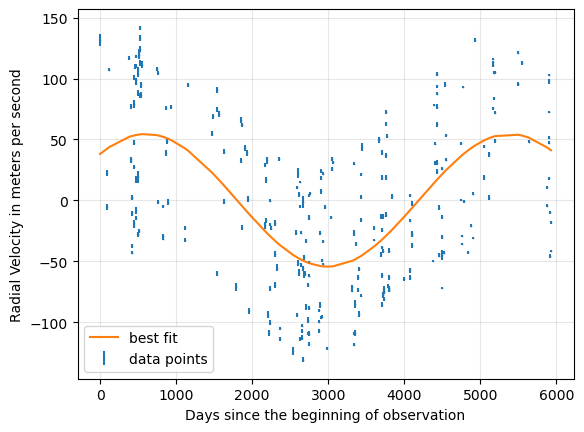

In [2]:
astrodata = ascii.read('astrodata.txt')                #extracting the data we want

def f_model(x,a,b,c,d):                                #defining our best of fit function
    return a*np.cos(2*np.pi*(x-b)/c) + d

#the data is in HJD, but those numbers are too large. therefore, they should be transformed to begin from 0 and still have the same interval lengths
#the labels are changed accordingly

nparray_x = np.array(astrodata['HJD']) #convert from ascii to numpy array data
nparray_subtract = np.full_like(nparray_x,2449676.0632) #creating an array and subtracting the minimum HJD value from each x-value (originally in HJD)
nparray_HJDtransform = nparray_x - nparray_subtract   #final result

f, ax = plt.subplots()        #creating plots
zerr = astrodata['Radial_Velocity_Uncertainty']
ax.errorbar(nparray_HJDtransform,astrodata['Radial_Velocity'],yerr=zerr,fmt='o',markersize=0.2,label='data points')

param_guess = [142.5,0,5927.74084,7.5]      #making use of scipy

#input the best-fit function, transformed x-coordinates, y-coordinates to fit to, and the guess

best_params, _ = optimize.curve_fit(f_model,nparray_HJDtransform,astrodata['Radial_Velocity'],p0=param_guess)
best_a = best_params[0] #set the optimized values to be equal to variables for later use
best_b = best_params[1]
best_c = best_params[2]
best_d = best_params[3]

y_fit = best_a*np.cos(2*np.pi*(nparray_HJDtransform-best_b)/best_c) + best_d    #graphing said best-fit function with the optimized values
ax.plot(nparray_HJDtransform,y_fit,label='best fit')           #legends and labels
ax.set_xlabel('Days since the beginning of observation')
ax.set_ylabel('Radial Velocity in meters per second')
plt.legend(loc=0)
plt.grid(alpha=0.3)

# At this point, it can be seen that the line cannot perfectly match the data.
# This mismatch can be quantified, as the value of the best-fit function can be subtracted from the original data for each input to find residuals.

The optimized amplitude value is 54.3927
The optimized period value is 4777.3519


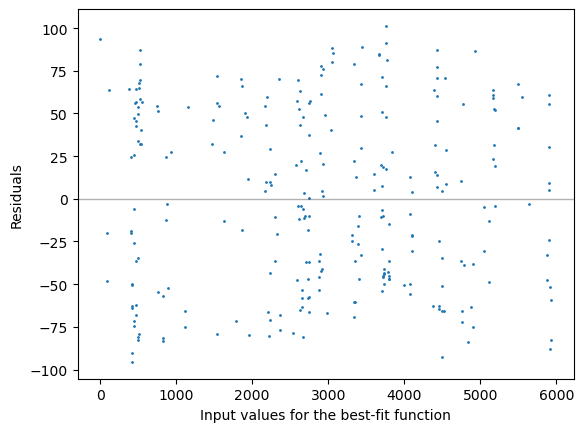

In [3]:
residuals = astrodata['Radial_Velocity'] - y_fit          #calculates the difference between the actual data and best-fit function


plt.plot(nparray_HJDtransform,residuals,'o',markersize=1)  #plotting said residuals
plt.xlabel('Input values for the best-fit function')
plt.ylabel('Residuals')
plt.axhline(y=0,color='k',alpha=0.3,linewidth=1.0)
print(f'The optimized amplitude value is {best_a:0.4f}')  #these values will be useful for later
print(f'The optimized period value is {best_c:0.4f}')

# A histogram better visualizes this data.
# The standard deviation of this data is also found, with a lower number indicating a curve which better fits the data.

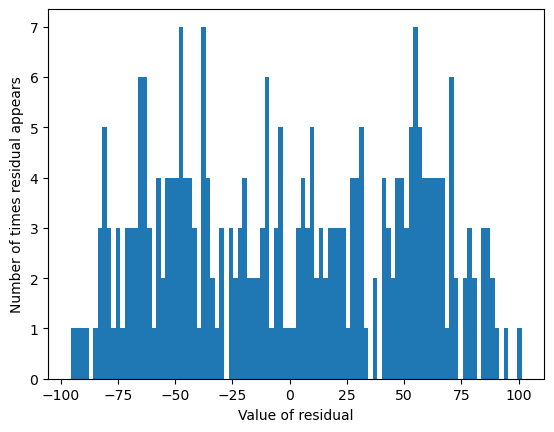

In [4]:
plt.hist(residuals,bins=100)      #creating histograms
plt.xlabel('Value of residual')
plt.ylabel('Number of times residual appears')
std_residuals = np.std(residuals)
mean_residuals = np.mean(residuals)

In [5]:
print(f'The standard deviation of the residuals is {std_residuals:0.4f}')

The standard deviation of the residuals is 51.9506


# At this point, the amplitude and period of the cosine function become useful.
# They are used to calculate the mass of the exoplanet from which the original data is measured.
# Searching for the stellar mass of the planetary system this exoplanet belongs to, that value is substituted in along with the best-fit amplitudes and periods.

In [6]:
K = best_a
P = best_c
M_EXO = (K/28.4) * ((P/365)**(1/3)) * (0.26)**(2/3)        #mass of the exoplanet in multiples of jupiter's mass
print(f'The estimated mass of the expoplanet is {M_EXO:0.3f} times Jupiter\'s mass.')

The estimated mass of the expoplanet is 1.839 times Jupiter's mass.


# The planet this analysis most closely fits is 55 Cnc d.